In [1]:
import EDEDE
import random as rd
import numpy as np
import matplotlib.pyplot as plt

Could not load cython functions. Some functionality might be broken.
Could not load sparse_dot_mkl. Will use scipy.sparse for matrix products.


In [2]:
tnets = []

n_per_group = 100
n_groups = 1
t_start = 0
t_end = 200

basis_num_communities = 2
powers_num_communities = [0]
list_p_within_community = [45/50] * len(powers_num_communities)

inter_tau_1 = 2
density_1 = 100

inter_tau_2 = 2
density_2 = 150

rd.seed = 314
for i in range(5):
    t_split = rd.randint(50, 150)
    # Phase 1: [t0, t_split]
    n1, s1, e1 = EDEDE.EDEDE(
        density=density_1, inter_tau=inter_tau_1, t_start=t_start, t_end=t_split, seed=1415+i)
    # Phase 2: [t_split, t_end]
    n2, s2, e2 = EDEDE.EDEDE(
        density=density_2, inter_tau=inter_tau_2, t_start=t_split, t_end=t_end, seed=8281+i
    )
    # Combine
    starts = np.concatenate([s1, s2])
    ends   = np.concatenate([e1, e2])

    tnet = EDEDE.generate_smooth_SBM(inter_tau =  0, density = 0,
                          n_per_group = n_per_group, n_groups =n_groups,
                          t_start = t_start, t_end =t_end,
                          basis_num_communities = basis_num_communities, powers_num_communities = powers_num_communities, list_p_within_community = list_p_within_community,
                          number_of_events = n1+n2, starting_times=starts, ending_times=ends, seed=271+i)
    
    tnets.append({'tnet': tnet, 't_split': t_split, 'starts': starts, 'ends': ends}) 

PID  97316  :  merged  1404  events
PID  97316  :  merged  0  events
PID  97316  :  merged  1108  events
PID  97316  :  merged  0  events
PID  97316  :  merged  1065  events
PID  97316  :  merged  0  events
PID  97316  :  merged  1232  events
PID  97316  :  merged  0  events
PID  97316  :  merged  1215  events
PID  97316  :  merged  0  events


In [3]:
for i in range(5):
    print(tnets[i]['t_split'])

74
124
148
120
108


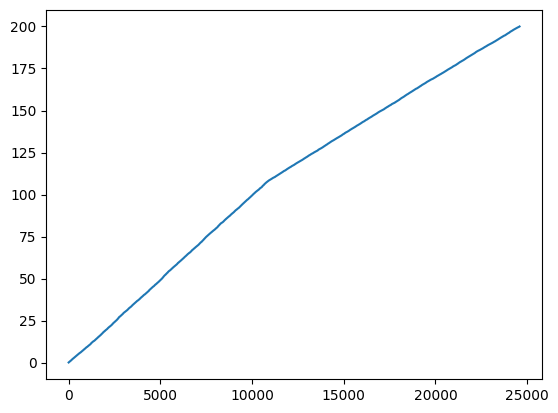

In [10]:
plt.plot(tnets[4]['starts'])

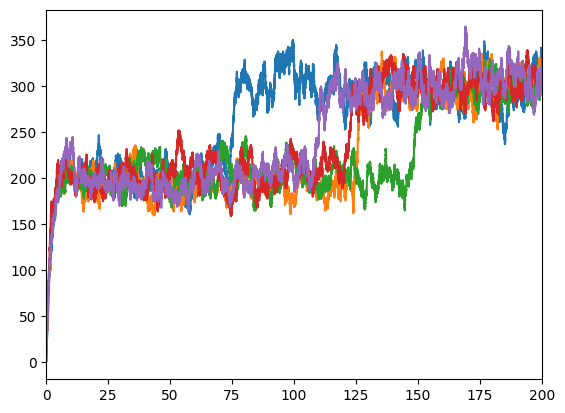

In [11]:
for i in range(5):
    starting_times = tnets[i]['starts']
    ending_times = tnets[i]['ends']

    change_times, counts_after = EDEDE.activity_EDEDE(starting_times, ending_times)
    plt.plot(change_times, counts_after)
    plt.xlim(0,200)

In [ ]:
tnets = []

n_per_group = 100
n_groups = 1
t_start = 0
t_end = 1000

basis_num_communities = 2
powers_num_communities = [0]
list_p_within_community = [45/50] * len(powers_num_communities)

inter_tau_1 = 100
density_1 = 1/2

inter_tau_2 = 200
density_2 = 1

t_split = 00 #rd.randint(450, 550)
# Phase 1: [t0, t_split]
n1, s1, e1 = EDEDE.EDEDE(
    density=density_1, inter_tau=inter_tau_1, t_start=t_start, t_end=t_split, seed=1415+i)

change_times, counts_after = EDEDE.activity_EDEDE(s1, e1)
plt.plot(change_times, counts_after)
plt.xlim(0,200)
plt.vlines(inter_tau_1 / 2 * np.log(inter_tau_1/density_1), ymin=0, ymax=np.max(counts_after), colors='r')

In [6]:
rho = density_1 * inter_tau_1
t_star = - inter_tau_1 * np.log((-1+np.sqrt(1 + 4 * rho))/ (2 * rho))

In [7]:
print(rho)
print(t_star)
print((-1+np.sqrt(1 + 4 * rho)))
print(np.log((-1+np.sqrt(1 + 4 * rho))/ (2 * rho)))

200
5.369013321555665
27.30194339616981
-2.6845066607778323


In [9]:
inter_tau_1 / 2 * np.log(density_1 * inter_tau_1)

np.float64(5.298317366548036)